# RealMLP Approach on Predicting Heart Disease

**Score**
- PB: 0.95396
- CV: 0.955666

**Note**
- Apply seed bagging
- Run CV with multiple seeds (e.g., 42, 2024, 7)
- Average predictions across seeds to produce the final output

### Package import

In [2]:
!pip install pytabkit -q

from pathlib import Path
import json
import zipfile
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import warnings
from sklearn.metrics import roc_auc_score
from pytabkit import RealMLP_TD_Classifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# ---- Config ----
COMP_SLUG = "playground-series-s6e2"
KAGGLE_COMP_DIR = Path("/kaggle/input/competitions/playground-series-s6e2")
KAGGLE_EXT_PATH = Path("/kaggle/input/datasets/neurocipher/heartdisease/Heart_Disease_Prediction.csv")

LOCAL_DATA_DIR = Path("data/raw")
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

NEED_FILES = ["train.csv", "test.csv", "sample_submission.csv"]

In [3]:
def run(cmd: list[str]) -> None:
    p = subprocess.run(cmd, capture_output=True, text=True)
    p.check_returncode()


def ensure_kaggle_cli() -> None:
    try:
        pass
    except Exception:
        subprocess.check_call(["pip", "-q", "install", "kaggle"])


def ensure_kaggle_json_interactive_colab(dst: Path = Path("/content/kaggle.json")) -> Path:
    """
    In Colab: open upload dialog if /content/kaggle.json is missing.
    In non-Colab: just require the file to exist.
    """
    if dst.exists():
        print("Found:", dst)
        return dst

    try:
        from google.colab import files  # type: ignore
    except Exception:
        raise FileNotFoundError(
            f"{dst} not found. Please place kaggle.json at {dst} (Colab) "
            "or provide credentials another way."
        )

    print("Upload your kaggle.json (Kaggle -> Account -> API -> Create New Token)")
    uploaded = files.upload()
    cand = None
    if "kaggle.json" in uploaded:
        cand = "kaggle.json"
    else:
        for name in uploaded.keys():
            if name.endswith(".json"):
                cand = name
                break
    if cand is None:
        raise FileNotFoundError("Upload failed: no .json file received.")

    Path(cand).rename(dst)
    print("Saved to:", dst)
    return dst


def install_kaggle_json(src: Path) -> None:
    """
    Copy /content/kaggle.json -> ~/.kaggle/kaggle.json (chmod 600)
    """
    if not src.exists():
        raise FileNotFoundError(f"{src} not found.")

    dst_dir = Path.home() / ".kaggle"
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / "kaggle.json"

    dst.write_bytes(src.read_bytes())
    try:
        dst.chmod(0o600)
    except Exception:
        pass

    cfg = json.loads(dst.read_text())
    if "username" not in cfg or "key" not in cfg:
        raise ValueError("kaggle.json is missing 'username' or 'key'.")
    print(f"Installed kaggle.json for user: {cfg['username']}")


def local_data_ready(data_dir: Path) -> bool:
    return all((data_dir / f).exists() for f in NEED_FILES)


def download_competition_to(data_dir: Path) -> None:
    """
    Download competition zip(s) and extract into data_dir.
    Assumes kaggle CLI + credentials are ready.
    """
    run(["kaggle", "config", "view"])
    run(["kaggle", "competitions", "download", "-c", COMP_SLUG, "-p", str(data_dir), "--force"])

    zips = list(data_dir.glob("*.zip"))
    if not zips:
        raise FileNotFoundError(f"No zip found in {data_dir} after download.")

    for zp in zips:
        with zipfile.ZipFile(zp, "r") as zf:
            zf.extractall(data_dir)
        print("Unzipped:", zp.name)

    if not local_data_ready(data_dir):
        missing = [f for f in NEED_FILES if not (data_dir / f).exists()]
        raise FileNotFoundError(f"Download/unzip finished but missing: {missing}")


In [4]:
if KAGGLE_COMP_DIR.exists():
    DATA_SRC = "kaggle"
    data_dir = KAGGLE_COMP_DIR
    print("Using Kaggle mounted competition data:", data_dir)
else:
    DATA_SRC = "local"
    data_dir = LOCAL_DATA_DIR
    if local_data_ready(data_dir):
        print("Using local data (already present):", data_dir)
    else:
        print("Local data missing -> download using kaggle.json")
        ensure_kaggle_cli()
        kaggle_json_src = ensure_kaggle_json_interactive_colab(Path("/content/kaggle.json"))
        install_kaggle_json(kaggle_json_src)
        download_competition_to(data_dir)
        print("Download complete -> using local data:", data_dir)


# ---- Load ----
train = pd.read_csv(data_dir / "train.csv")
test  = pd.read_csv(data_dir / "test.csv")
sub   = pd.read_csv(data_dir / "sample_submission.csv")

# external dataset: only available if mounted on Kaggle; optional
original = pd.read_csv(KAGGLE_EXT_PATH) if KAGGLE_EXT_PATH.exists() else None

print("train:", train.shape, "test:", test.shape, "sub:", sub.shape, "original:", None if original is None else original.shape)
print("DATA_SRC:", DATA_SRC)

# External data loading
train_comp = train.copy()

# Encode target with LabelEncoder if not numeric
if not pd.api.types.is_numeric_dtype(train_comp["Heart Disease"]):
    le = LabelEncoder()
    train_comp["Heart Disease"] = le.fit_transform(train_comp["Heart Disease"])
    if original is not None and "Heart Disease" in original.columns:
        original["Heart Disease"] = le.transform(original["Heart Disease"])

# Align external columns to train schema
if original is not None:
    if "Heart Disease" not in original.columns:
        raise ValueError("External dataset missing target column: Heart Disease")

    original_aligned = original.copy()
    # add missing columns
    for col in train_comp.columns:
        if col not in original_aligned.columns:
            original_aligned[col] = np.nan

    # ensure id exists
    if "id" not in original_aligned.columns:
        original_aligned["id"] = -(np.arange(len(original_aligned)) + 1)

    # align column order
    original_aligned = original_aligned[train_comp.columns]

    train_full = pd.concat([train_comp, original_aligned], ignore_index=True)
    train_full["is_external"] = [0] * len(train_comp) + [1] * len(original_aligned)
else:
    train_full = train_comp.copy()
    train_full["is_external"] = 0

# use concatenated data for downstream
train = train_full


Local data missing -> download using kaggle.json
Upload your kaggle.json (Kaggle -> Account -> API -> Create New Token)


Saving kaggle.json to kaggle.json
Saved to: /content/kaggle.json
Installed kaggle.json for user: bloodymonday
Unzipped: playground-series-s6e2.zip
Download complete -> using local data: data/raw
train: (630000, 15) test: (270000, 14) sub: (270000, 2) original: None
DATA_SRC: local


In [5]:
import random

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_STATE = 42

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)

if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.set_float32_matmul_precision("high")
N_FOLDS = 5
USE_ALL_CAT = True

print(f"Using device: {DEVICE}")


Using device: cuda


### Data download

In [6]:
display(train.head())
display(test.head())
display(sub.head())

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,is_external
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1,0
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1,0


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


,id,Heart Disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


In [7]:
# Shapes
print("train:", train.shape)
print("test:", test.shape)

# Column diffs
train_cols = set(train.columns)
test_cols = set(test.columns)
print("Only in train:", sorted(train_cols - test_cols))
print("Only in test:", sorted(test_cols - train_cols))

# dtypes
train.dtypes.to_frame("dtype").head(30)


train: (630000, 16)
test: (270000, 14)
Only in train: ['Heart Disease', 'is_external']
Only in test: []


,dtype
id,int64
Age,int64
Sex,int64
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64


### Data Preprocessing

In [8]:
def encode_target_strict(y: pd.Series) -> pd.Series:
    """Map common string labels to {0,1}. Raises if unknown."""
    mapping_candidates = [
        {"No": 0, "Yes": 1},
        {"N": 0, "Y": 1},
        {"Negative": 0, "Positive": 1},
        {"Absent": 0, "Present": 1},
        {"Absence": 0, "Presence": 1},
        {0: 0, 1: 1},
        {"0": 0, "1": 1},
    ]
    uniq = set(pd.Series(y).dropna().unique().tolist())
    for mp in mapping_candidates:
        if uniq.issubset(set(mp.keys())):
            return pd.Series(y).map(mp).astype("int8")
    raise ValueError(f"Unknown target labels: {sorted(list(uniq))}")


# ---- target ----
if not pd.api.types.is_numeric_dtype(train["Heart Disease"]):
    train["Heart Disease"] = encode_target_strict(train["Heart Disease"])
if original is not None and "Heart Disease" in original.columns:
    if not pd.api.types.is_numeric_dtype(original["Heart Disease"]):
        original["Heart Disease"] = encode_target_strict(original["Heart Disease"])

TARGET_COL = "Heart Disease"
ID_COL = "id"
META_COLS = [TARGET_COL, ID_COL, "is_external"]

BASE_FEATURES = [c for c in train.columns if c not in META_COLS]

# Canonical S6E2 semantic categoricals (keep as category for embeddings/encoding)
CANONICAL_CAT = {
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium",
}

def split_cols(df: pd.DataFrame):
    base = [c for c in df.columns if c not in META_COLS]
    cat = [c for c in base if c in CANONICAL_CAT]
    num = [c for c in base if c not in cat]
    return cat, num


def add_external_target_stats(df: pd.DataFrame, original_df: pd.DataFrame | None) -> pd.DataFrame:
    """Merge group-wise target stats from the external/original dataset.
    Safe in Playground comps because original_df labels are not the competition labels.
    """
    if original_df is None:
        return df.copy()

    out = df.copy()
    initial_rows = len(out)

    for col in BASE_FEATURES:
        if col not in original_df.columns:
            continue

        stats = (
            original_df.groupby(col)[TARGET_COL]
            .agg(["mean", "median", "std", "skew", "count"])
            .reset_index()
        )
        stats.columns = [col] + [f"orig_{col}_{s}" for s in ["mean", "median", "std", "skew", "count"]]

        out = out.merge(stats, on=col, how="left")
        if len(out) != initial_rows:
            raise ValueError(f"Merge expanded rows for column {col}! {initial_rows} -> {len(out)}")

        # fill NAs for unseen values
        global_mean = float(original_df[TARGET_COL].mean())
        global_median = float(original_df[TARGET_COL].median())
        fill = {
            f"orig_{col}_mean": global_mean,
            f"orig_{col}_median": global_median,
            f"orig_{col}_std": 0.0,
            f"orig_{col}_skew": 0.0,
            f"orig_{col}_count": 0.0,
        }
        out = out.fillna(value=fill)

    return out


def add_frequency_encoding(train_df: pd.DataFrame, test_df: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Add {col}_freq columns using combined train+test frequencies (unsupervised, safe)."""
    tr = train_df.copy()
    te = test_df.copy()

    combined = pd.concat([tr[cols], te[cols]], axis=0, ignore_index=True)
    for col in cols:
        freq = combined[col].value_counts(dropna=False)
        tr[f"{col}_freq"] = tr[col].map(freq).astype("float32")
        te[f"{col}_freq"] = te[col].map(freq).astype("float32")
    return tr, te


def add_binned_numerics(train_df: pd.DataFrame, test_df: pd.DataFrame, num_cols: list[str], n_bins: int = 10):
    tr = train_df.copy()
    te = test_df.copy()

    for col in num_cols:
        allv = pd.concat([tr[col], te[col]], axis=0, ignore_index=True)

        # If low cardinality, just reuse as "bin" (stable int codes)
        if allv.nunique(dropna=False) <= n_bins:
            tr[f"{col}_bin"] = pd.Series(tr[col]).astype("int32", errors="ignore")
            te[f"{col}_bin"] = pd.Series(te[col]).astype("int32", errors="ignore")
            continue

        try:
            bins = pd.qcut(allv.rank(method="first"), q=n_bins, labels=False, duplicates="drop")
        except Exception:
            bins = pd.cut(allv, bins=n_bins, labels=False, duplicates="drop")

        tr[f"{col}_bin"] = bins.iloc[:len(tr)].astype("int16")
        te[f"{col}_bin"] = bins.iloc[len(tr):].astype("int16")

    return tr, te


def build_features(
    train_fe: pd.DataFrame,
    test_fe: pd.DataFrame,
    cat_cols: list[str],
    num_cols: list[str],
    use_bins: bool,
):
    tr = train_fe.copy()
    te = test_fe.copy()

    if use_bins:
        # Add binned versions of continuous numerics (helps linear/MLP; low risk for GBDT too)
        # Important: keep 'orig_*' stats as numeric; they are already in num_cols here.
        # bin only "base continuous" numerics (exclude orig_* stats)
        num_cols_for_bins = [c for c in num_cols if not c.startswith("orig_")]
        tr, te = add_binned_numerics(tr, te, num_cols_for_bins, n_bins=10)

    print(f"Train Shape after FE: {tr.shape}")
    print(f"Test Shape after FE:  {te.shape}")

    # ---- Build X/y with clean dtypes ----
    drop_tr = [c for c in META_COLS if c in tr.columns]
    drop_te = [c for c in [ID_COL] if c in te.columns]

    X = tr.drop(columns=drop_tr).copy()
    X_test = te.drop(columns=drop_te).copy()
    y = tr[TARGET_COL].copy()

    bin_cols = [c for c in X.columns if c.endswith("_bin")]

    cat_cols_final = [c for c in X.columns if c in cat_cols] + (bin_cols if use_bins else [])
    num_cols_final = [c for c in X.columns if c not in cat_cols_final]

    for c in cat_cols_final:
        combined = pd.concat([X[c], X_test[c]], axis=0, ignore_index=True)
        cats = pd.Categorical(combined).categories
        X[c] = pd.Categorical(X[c], categories=cats)
        X_test[c] = pd.Categorical(X_test[c], categories=cats)

    for c in num_cols_final:
        X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")
        X_test[c] = pd.to_numeric(X_test[c], errors="coerce").astype("float32")

    return X, X_test, y, cat_cols_final, num_cols_final


# ---- Feature engineering (per EDA) ----
train_fe = add_external_target_stats(train, original)
test_fe  = add_external_target_stats(test, original)

cat_cols, num_cols = split_cols(train_fe)

# Frequency encoding for semantic categoricals
train_fe, test_fe = add_frequency_encoding(train_fe, test_fe, cat_cols)

CONFIGS = {
    "categorical_binned": True,
    "numeric_continuous": False,
}

features = {}
for name, use_bins in CONFIGS.items():
    print(f"=== Building features: {name} (use_bins={use_bins}) ===")
    X_tmp, X_test_tmp, y_tmp, cat_cols_final, num_cols_final = build_features(
        train_fe, test_fe, cat_cols, num_cols, use_bins
    )

    if use_bins:
        assert any(c.endswith("_bin") for c in X_tmp.columns)
    else:
        assert not any(c.endswith("_bin") for c in X_tmp.columns)

    assert all(str(X_tmp[c].dtype) == "category" for c in cat_cols_final)
    assert all(X_tmp[c].dtype == "float32" for c in num_cols_final)

    print("Categorical cols:", len(cat_cols_final))
    print("Numeric cols:", len(num_cols_final))

    features[name] = {
        "X": X_tmp,
        "X_test": X_test_tmp,
        "y": y_tmp,
        "cat_cols": cat_cols_final,
        "num_cols": num_cols_final,
    }

# Default config for downstream cells
PRIMARY_CONFIG = "categorical_binned"
X = features[PRIMARY_CONFIG]["X"]
X_test = features[PRIMARY_CONFIG]["X_test"]
y = features[PRIMARY_CONFIG]["y"]
cat_cols = features[PRIMARY_CONFIG]["cat_cols"]

print(f"\nPRIMARY_CONFIG={PRIMARY_CONFIG}")
print(f"X: {X.shape}, X_test: {X_test.shape}, y: {y.shape}")


=== Building features: categorical_binned (use_bins=True) ===
Train Shape after FE: (630000, 29)
Test Shape after FE:  (270000, 27)
Categorical cols: 13
Numeric cols: 13
=== Building features: numeric_continuous (use_bins=False) ===
Train Shape after FE: (630000, 24)
Test Shape after FE:  (270000, 22)
Categorical cols: 8
Numeric cols: 13

PRIMARY_CONFIG=categorical_binned
X: (630000, 26), X_test: (270000, 26), y: (630000,)


### Data Quality Check

In [9]:
def check_data_quality(df, name="Dataset"):
    print(f"--- Data Quality: {name} ---")
    print(f"Total Rows: {len(df)}")

    cols_to_check = [c for c in df.columns if c != 'id']
    dupes = df.duplicated(subset=cols_to_check).sum()

    nan_counts = df.isnull().sum()
    total_nans = nan_counts.sum()

    print(f"Duplicate Rows (excl. ID): {dupes}")
    print(f"Total NaN values: {total_nans}")
    if total_nans > 0:
        print("\nColumns with NaNs:")
        print(nan_counts[nan_counts > 0])
    print("-" * 30)

check_data_quality(train, "Train")
check_data_quality(test, "Test")

--- Data Quality: Train ---
Total Rows: 630000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------
--- Data Quality: Test ---
Total Rows: 270000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------


### Feature Uniqueness & Cardinality

In [10]:
# Target distribution analysis

def analyze_uniqueness(df):
    unique_stats = []
    for col in df.columns:
        if col == 'id':
            continue

        n_unique = df[col].nunique()
        dtype = df[col].dtype

        category_guess = "Categorical/Ordinal" if n_unique < 25 else "Continuous"

        if pd.api.types.is_numeric_dtype(df[col]):
            mean_val = float(pd.to_numeric(df[col], errors='coerce').mean())
            std_val = float(pd.to_numeric(df[col], errors='coerce').std())
        else:
            mean_val = float('nan')
            std_val = float('nan')

        unique_stats.append({
            'Feature': col,
            'Unique Values': n_unique,
            'Data Type': dtype,
            'Heuristic Type': category_guess,
            'Mean': mean_val,
            'Std': std_val,
        })

    return pd.DataFrame(unique_stats).sort_values(by='Unique Values')

# class imbalance
comp_mask = (train["is_external"] == 0)
ext_mask  = (train["is_external"] == 1)

print("=== Target distribution: COMP ONLY ===")
print(train.loc[comp_mask, TARGET_COL].value_counts(dropna=False))
print(train.loc[comp_mask, TARGET_COL].value_counts(normalize=True, dropna=False))

print("\n=== Target distribution: EXTERNAL ONLY ===")
print(train.loc[ext_mask, TARGET_COL].value_counts(dropna=False))
print(train.loc[ext_mask, TARGET_COL].value_counts(normalize=True, dropna=False))

print("\n=== Target distribution: MERGED (comp + external) ===")
print(train[TARGET_COL].value_counts(dropna=False))
print(train[TARGET_COL].value_counts(normalize=True, dropna=False))

uniqueness_df = analyze_uniqueness(train)
uniqueness_df


=== Target distribution: COMP ONLY ===
Heart Disease
0    347546
1    282454
Name: count, dtype: int64
Heart Disease
0    0.55166
1    0.44834
Name: proportion, dtype: float64

=== Target distribution: EXTERNAL ONLY ===
Series([], Name: count, dtype: int64)
Series([], Name: proportion, dtype: float64)

=== Target distribution: MERGED (comp + external) ===
Heart Disease
0    347546
1    282454
Name: count, dtype: int64
Heart Disease
0    0.55166
1    0.44834
Name: proportion, dtype: float64


,Feature,Unique Values,Data Type,Heuristic Type,Mean,Std
14,is_external,1,int64,Categorical/Ordinal,0.000000,0.000000
1,Sex,2,int64,Categorical/Ordinal,0.714735,0.451541
8,Exercise angina,2,int64,Categorical/Ordinal,0.273725,0.445870
5,FBS over 120,2,int64,Categorical/Ordinal,0.079987,0.271274
13,Heart Disease,2,int64,Categorical/Ordinal,0.448340,0.497324
10,Slope of ST,3,int64,Categorical/Ordinal,1.455871,0.545192
6,EKG results,3,int64,Categorical/Ordinal,0.981660,0.998783
12,Thallium,3,int64,Categorical/Ordinal,4.618873,1.950007
2,Chest pain type,4,int64,Categorical/Ordinal,3.312752,0.851615
11,Number of vessels fluro,4,int64,Categorical/Ordinal,0.451040,0.798549


### Visualize Top Skewed Features

Top 6 Most Skewed Features (Absolute Values):
EKG results_freq       -16.972622
FBS over 120_freq       -3.096606
Slope of ST_freq        -1.947209
Thallium_freq           -1.354339
ST depression            1.328429
Exercise angina_freq    -1.014983
dtype: float32


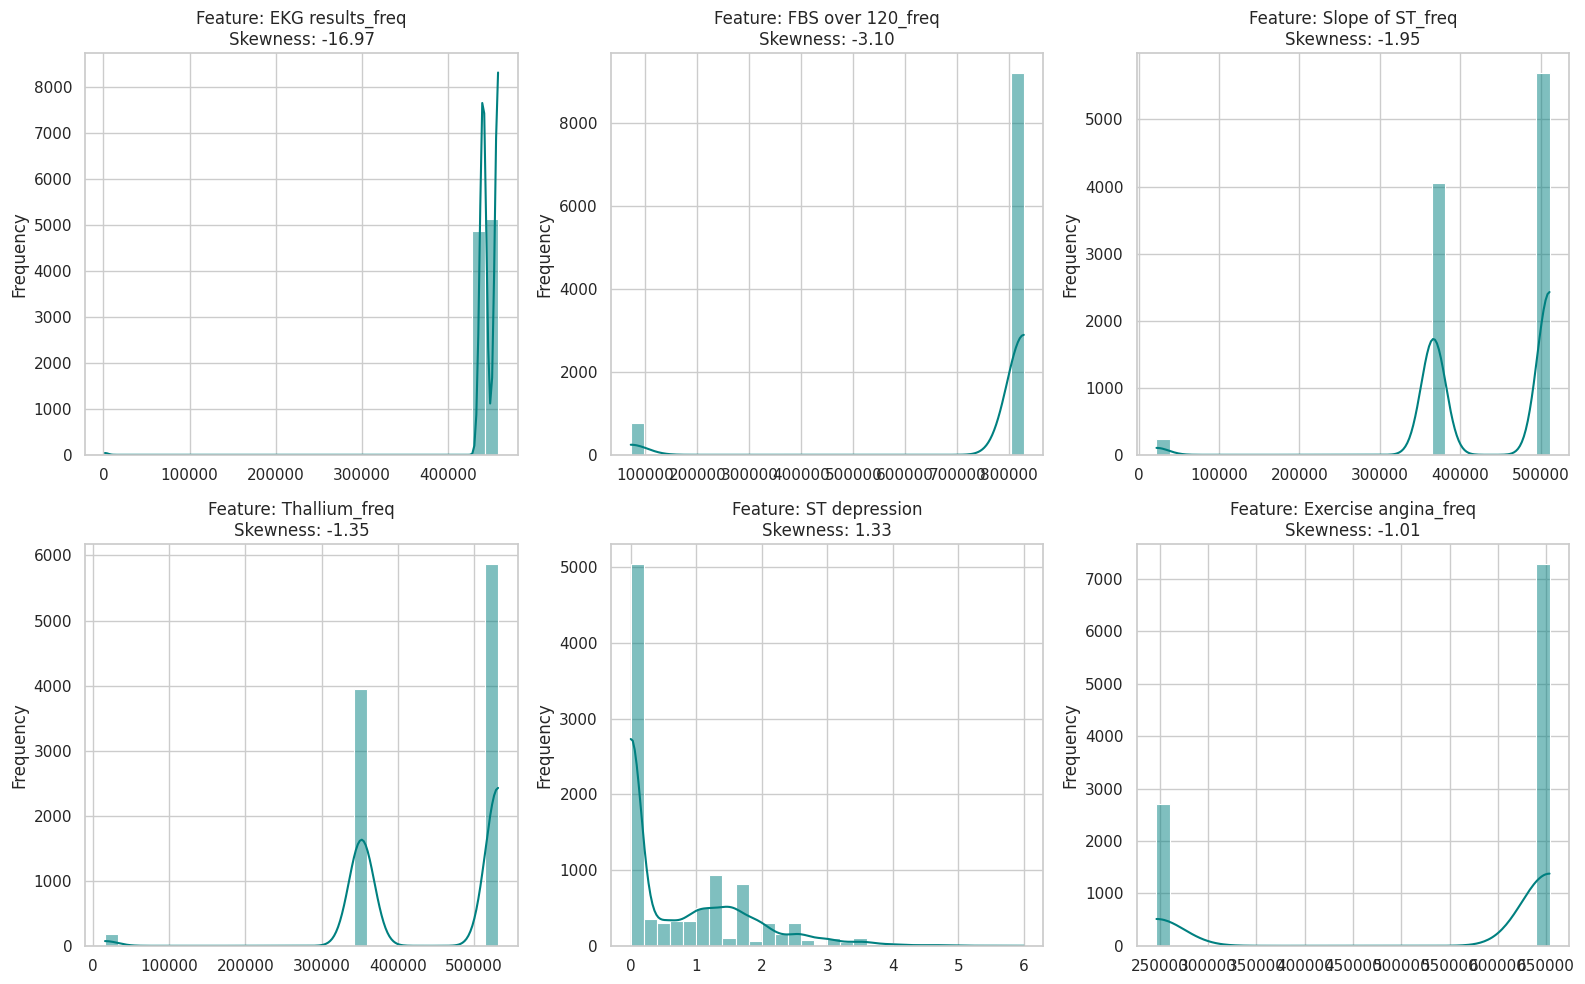

In [11]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

skew_series = X[numeric_cols].skew().abs().sort_values(ascending=False)
top_skewed_features = skew_series.head(6).index.tolist()

print("Top 6 Most Skewed Features (Absolute Values):")
print(X[top_skewed_features].skew())

plt.figure(figsize=(16, 10))
for i, col in enumerate(top_skewed_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(X[col].sample(min(10000, len(X))), kde=True, color='teal', bins=30)
    plt.title(f"Feature: {col}\nSkewness: {X[col].skew():.2f}")
    plt.xlabel("")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Cross-Validation & Training

In [14]:
%%time

# =========================
# Fixed params (Best from HPO)
# =========================
N_FOLDS = 5
SEEDS = [42, 2024, 7]
PRIMARY_CONFIG = "numeric_continuous"

params = {
    "device": DEVICE,              # "cuda" or "cpu"
    'random_state': 42,
    'verbosity': 2,
    'n_epochs': 100,
    'batch_size': 2**12,
    'n_ens': 8,
    'use_early_stopping': True,
    'early_stopping_additive_patience': 20,
    'early_stopping_multiplicative_patience': 1,
    'act': "mish",
    'embedding_size': 8,
    'first_layer_lr_factor': 0.5962121993798933,
    'hidden_sizes': "rectangular",
    'hidden_width': 384,
    'lr': 0.04,
    'ls_eps': 0.011498317194338772,
    'ls_eps_sched': "coslog4",
    'max_one_hot_cat_size': 18,
    'n_hidden_layers': 4,
    'p_drop': 0.07301419697186451,
    'p_drop_sched': "flat_cos",
    'plr_hidden_1': 16,
    'plr_hidden_2': 8,
    'plr_lr_factor': 0.1151437622270563,
    'plr_sigma': 2.3316811282666916,
    'scale_lr_factor': 2.244801835541429,
    'sq_mom': 1.0 - 0.011834054955582318,
    'wd': 0.02369230879235962,
}

CPU times: user 13 µs, sys: 1 µs, total: 14 µs
Wall time: 18.4 µs


In [15]:
import time
from datetime import datetime
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

feat = features[PRIMARY_CONFIG]
X = feat["X"].copy()
X_test = feat["X_test"].copy()
y = feat["y"].copy()

# OOF prediction
# Cast all features to categorical strings to match ext notebook behavior
for col in X.columns:
    X[col] = X[col].astype(str).astype("category")
    X_test[col] = X_test[col].astype(str).astype("category")

oof_preds_seeds = []
test_preds_seeds = []
seed_oof_scores = []
seed_fold_scores = []

t_total_start = time.time()

for seed_idx, seed in enumerate(SEEDS, start=1):
    print(f"\n{'#'*55}")
    print(f"  Seed {seed_idx}/{len(SEEDS)} : {seed}")
    print(f"{'#'*55}")

    set_seed(seed)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

    oof_preds_seed = np.zeros(len(X), dtype=np.float32)
    test_preds_seed = np.zeros(len(X_test), dtype=np.float32)
    fold_scores = []

    t_seed_start = time.time()

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        t_fold_start = time.time()

        print(f"\n{'='*55}")
        print(f"  Seed {seed} | Fold {fold}/{N_FOLDS} | started at {datetime.now().strftime('%H:%M:%S')}")
        print(f"{'='*55}")

        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]

        SUB_FRAC = 0.1
        sss = StratifiedShuffleSplit(
            n_splits=1,
            train_size=int(len(X_tr) * SUB_FRAC),
            random_state=RANDOM_STATE + fold
        )
        sub_idx, _ = next(sss.split(X_tr, y_tr))
        X_tr = X_tr.iloc[sub_idx]
        y_tr = y_tr.iloc[sub_idx]

        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        print(f"  [data]  train={len(X_tr):,}  val={len(X_val):,}  "
              f"pos_rate(tr)={y_tr.mean():.3f}  pos_rate(val)={y_val.mean():.3f}")

        print(f"  [fit]   starting RealMLP_TD training ...")
        t_fit = time.time()
        params_seed = params.copy()
        params_seed["random_state"] = seed
        model = RealMLP_TD_Classifier(**params_seed)
        model.fit(X_tr, y_tr.values, X_val, y_val.values)
        print(f"  [fit]   done in {time.time()-t_fit:.1f}s")

        print(f"  [pred]  predicting val & test ...")
        val_probs  = model.predict_proba(X_val)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]

        oof_preds_seed[val_idx] = val_probs
        test_preds_seed += test_probs / N_FOLDS

        score = roc_auc_score(y_val, val_probs)
        fold_scores.append(score)

        elapsed = time.time() - t_fold_start
        total_elapsed = time.time() - t_seed_start
        eta = (total_elapsed / fold) * (N_FOLDS - fold)

        print(f"\n  Fold {fold} AUC : {score:.5f}")
        print(f"  Scores so far : {[round(s,5) for s in fold_scores]}")
        print(f"  Running mean  : {np.mean(fold_scores):.5f}  ±  {np.std(fold_scores):.5f}")
        print(f"  Fold time     : {elapsed:.1f}s  |  Seed total: {total_elapsed:.1f}s  |  ETA: {eta:.1f}s")

        if DEVICE == "cuda":
            torch.cuda.empty_cache()
            print("  [cuda]  cache cleared")

    seed_time = time.time() - t_seed_start
    seed_oof_auc = float(roc_auc_score(y, oof_preds_seed))

    oof_preds_seeds.append(oof_preds_seed)
    test_preds_seeds.append(test_preds_seed)
    seed_oof_scores.append(seed_oof_auc)
    seed_fold_scores.append(fold_scores)

    print(f"\n{'-'*55}")
    print(f"  Seed {seed} summary")
    print(f"  Fold scores : {[round(s,6) for s in fold_scores]}")
    print(f"  Mean AUC    : {np.mean(fold_scores):.6f}")
    print(f"  Std AUC     : {np.std(fold_scores):.6f}")
    print(f"  OOF AUC     : {seed_oof_auc:.6f}")
    print(f"  Seed time   : {seed_time:.1f}s  ({seed_time/60:.1f}min)")
    print(f"{'-'*55}")

# ── シード平均（bagging） ─────────────────────────────
oof_preds  = np.mean(np.vstack(oof_preds_seeds), axis=0)
test_preds = np.mean(np.vstack(test_preds_seeds), axis=0)

total_time    = time.time() - t_total_start
mean_seed_auc = float(np.mean(seed_oof_scores))
std_seed_auc  = float(np.std(seed_oof_scores))
oof_auc       = float(roc_auc_score(y, oof_preds))

print(f"\n{'#'*55}")
print(f"  CV SUMMARY (Seed Bagging)")
print(f"{'#'*55}")
print(f"  Seeds         : {SEEDS}")
print(f"  Seed OOF AUCs : {[round(s,6) for s in seed_oof_scores]}")
print(f"  Mean Seed AUC : {mean_seed_auc:.6f}")
print(f"  Std  Seed AUC : {std_seed_auc:.6f}")
print(f"  Bagged OOF    : {oof_auc:.6f}")
print(f"  Total time    : {total_time:.1f}s  ({total_time/60:.1f}min)")
print(f"{'#'*55}")



#######################################################
  Seed 1/3 : 42
#######################################################

  Seed 42 | Fold 1/5 | started at 00:16:23
  [data]  train=50,400  val=126,000  pos_rate(tr)=0.448  pos_rate(val)=0.448
  [fit]   starting RealMLP_TD training ...
Columns classified as continuous: []
Columns classified as categorical: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Sex_freq', 'Chest pain type_freq', 'FBS over 120_freq', 'EKG results_freq', 'Exercise angina_freq', 'Slope of ST_freq', 'Number of vessels fluro_freq', 'Thallium_freq']


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/100: val class_error = 0.131762
Epoch 2/100: val class_error = 0.121563
Epoch 3/100: val class_error = 0.116849
Epoch 4/100: val class_error = 0.112929
Epoch 5/100: val class_error = 0.112024
Epoch 6/100: val class_error = 0.111897
Epoch 7/100: val class_error = 0.111841
Epoch 8/100: val class_error = 0.111778
Epoch 9/100: val class_error = 0.111405
Epoch 10/100: val class_error = 0.111500
Epoch 11/100: val class_error = 0.111159
Epoch 12/100: val class_error = 0.111127
Epoch 13/100: val class_error = 0.110571
Epoch 14/100: val class_error = 0.110659
Epoch 15/100: val class_error = 0.110659
Epoch 16/100: val class_error = 0.110698
Epoch 17/100: val class_error = 0.110786
Epoch 18/100: val class_error = 0.110794
Epoch 19/100: val class_error = 0.110683
Epoch 20/100: val class_error = 0.110706
Epoch 21/100: val class_error = 0.110683
Epoch 22/100: val class_error = 0.110722
Epoch 23/100: val class_error = 0.110825
Epoch 24/100: val class_error = 0.110762
Epoch 25/100: val class_e

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cud


  Fold 1 AUC : 0.95519
  Scores so far : [np.float64(0.95519)]
  Running mean  : 0.95519  ±  0.00000
  Fold time     : 64.0s  |  Seed total: 64.1s  |  ETA: 256.4s
  [cuda]  cache cleared

  Seed 42 | Fold 2/5 | started at 00:17:27
  [data]  train=50,400  val=126,000  pos_rate(tr)=0.448  pos_rate(val)=0.448
  [fit]   starting RealMLP_TD training ...
Columns classified as continuous: []
Columns classified as categorical: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Sex_freq', 'Chest pain type_freq', 'FBS over 120_freq', 'EKG results_freq', 'Exercise angina_freq', 'Slope of ST_freq', 'Number of vessels fluro_freq', 'Thallium_freq']


...


  Fold 4 AUC : 0.95523
  Scores so far : [np.float64(0.95463), np.float64(0.95501), np.float64(0.95428), np.float64(0.95523)]
  Running mean  : 0.95479  ±  0.00037
  Fold time     : 78.1s  |  Seed total: 325.5s  |  ETA: 81.4s
  [cuda]  cache cleared

  Seed 7 | Fold 5/5 | started at 00:34:54
  [data]  train=50,400  val=126,000  pos_rate(tr)=0.448  pos_rate(val)=0.448
  [fit]   starting RealMLP_TD training ...
Columns classified as continuous: []
Columns classified as categorical: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Sex_freq', 'Chest pain type_freq', 'FBS over 120_freq', 'EKG results_freq', 'Exercise angina_freq', 'Slope of ST_freq', 'Number of vessels fluro_freq', 'Thallium_freq']


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/100: val class_error = 0.136127
Epoch 2/100: val class_error = 0.124413
Epoch 3/100: val class_error = 0.119167
Epoch 4/100: val class_error = 0.115413
Epoch 5/100: val class_error = 0.114206
Epoch 6/100: val class_error = 0.113389
Epoch 7/100: val class_error = 0.113333
Epoch 8/100: val class_error = 0.113429
Epoch 9/100: val class_error = 0.112944
Epoch 10/100: val class_error = 0.112524
Epoch 11/100: val class_error = 0.112929
Epoch 12/100: val class_error = 0.111849
Epoch 13/100: val class_error = 0.111968
Epoch 14/100: val class_error = 0.111770
Epoch 15/100: val class_error = 0.111944
Epoch 16/100: val class_error = 0.111889
Epoch 17/100: val class_error = 0.111968
Epoch 18/100: val class_error = 0.112167
Epoch 19/100: val class_error = 0.112016
Epoch 20/100: val class_error = 0.112071
Epoch 21/100: val class_error = 0.112071
Epoch 22/100: val class_error = 0.112056
Epoch 23/100: val class_error = 0.112183
Epoch 24/100: val class_error = 0.112302
Epoch 25/100: val class_e

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cud


  Fold 5 AUC : 0.95470
  Scores so far : [np.float64(0.95463), np.float64(0.95501), np.float64(0.95428), np.float64(0.95523), np.float64(0.9547)]
  Running mean  : 0.95477  ±  0.00033
  Fold time     : 74.2s  |  Seed total: 399.7s  |  ETA: 0.0s
  [cuda]  cache cleared

-------------------------------------------------------
  Seed 7 summary
  Fold scores : [np.float64(0.954628), np.float64(0.955012), np.float64(0.954277), np.float64(0.955235), np.float64(0.954704)]
  Mean AUC    : 0.954771
  Std AUC     : 0.000329
  OOF AUC     : 0.954673
  Seed time   : 399.7s  (6.7min)
-------------------------------------------------------

#######################################################
  CV SUMMARY (Seed Bagging)
#######################################################
  Seeds         : [42, 2024, 7]
  Seed OOF AUCs : [0.954653, 0.954671, 0.954673]
  Mean Seed AUC : 0.954666
  Std  Seed AUC : 0.000009
  Bagged OOF    : 0.955311
  Total time    : 1184.6s  (19.7min)
#########################

### Model Evaluation

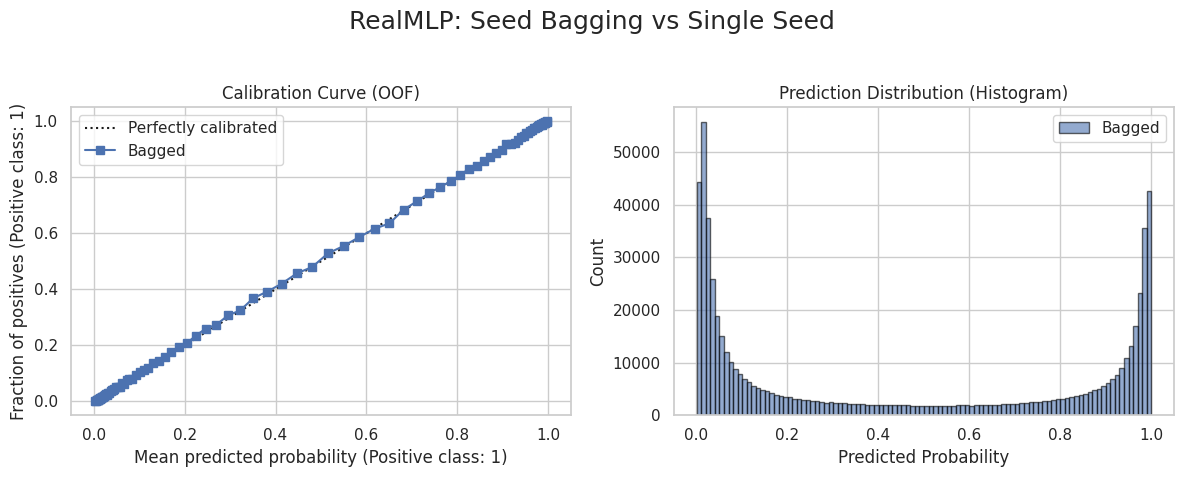

In [18]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(12, 5))
plt.suptitle('RealMLP: Seed Bagging vs Single Seed', fontsize=18)

ax1 = plt.subplot(1, 2, 1)
CalibrationDisplay.from_predictions(
    y, oof_preds, n_bins=100, strategy='quantile', ax=ax1, name='Bagged'
)
ax1.set_title('Calibration Curve (OOF)')
ax1.legend()

ax2 = plt.subplot(1, 2, 2)
ax2.hist(oof_preds, bins=100, edgecolor='black', alpha=0.6, label='Bagged')
ax2.set_title('Prediction Distribution (Histogram)')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


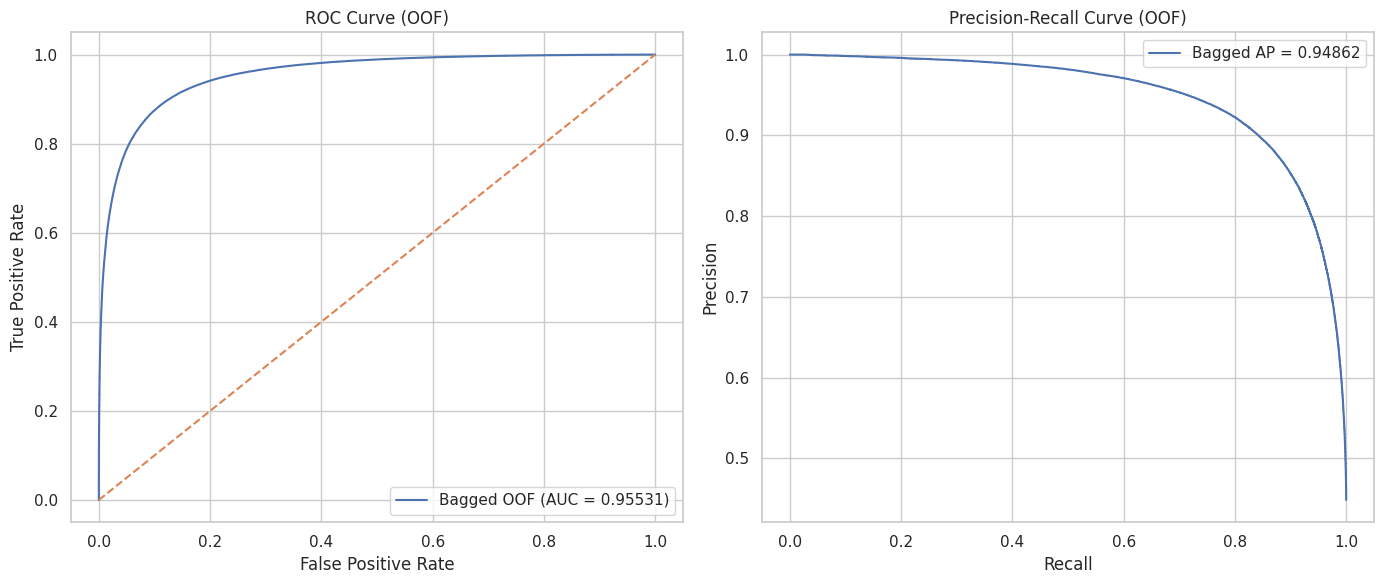

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Create figure with 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---- ROC Curve ----
fpr_b, tpr_b, _ = roc_curve(y, oof_preds)
roc_auc_b = auc(fpr_b, tpr_b)

ax1.plot(fpr_b, tpr_b, label=f'Bagged OOF (AUC = {roc_auc_b:.5f})')
ax1.plot([0, 1], [0, 1], linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve (OOF)')
ax1.legend()
ax1.grid(True)

# ---- Precision-Recall Curve ----
precision_b, recall_b, _ = precision_recall_curve(y, oof_preds)
ap_b = average_precision_score(y, oof_preds)


ax2.plot(recall_b, precision_b, label=f'Bagged AP = {ap_b:.5f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve (OOF)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

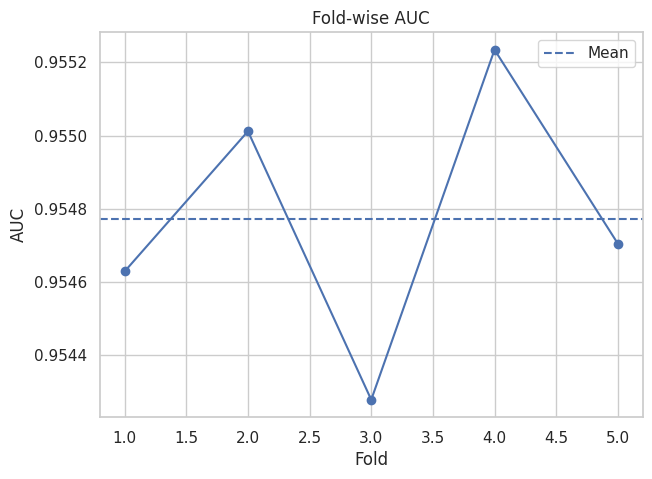

In [26]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, N_FOLDS+1), fold_scores, marker='o')
plt.axhline(np.mean(fold_scores), linestyle='--', label='Mean')

plt.xlabel('Fold')
plt.ylabel('AUC')
plt.title('Fold-wise AUC')
plt.legend()
plt.grid(True)
plt.show()


### Evaluation and Submission

In [27]:
total_oof_score = roc_auc_score(y, oof_preds)

print("\n" + "="*40)
print(f"Overall OOF ROC-AUC (avg OOF): {total_oof_score:.5f}")
print("="*40)

# Save OOF predictions for competition train rows only
comp_len = len(train_comp)
comp_oof = oof_preds[:comp_len]
comp_ids = train_comp['id'].values
pd.DataFrame({'id': comp_ids, 'Heart Disease_prob': comp_oof}).to_csv('oof_preds_train.csv', index=False)
print('OOF predictions saved to oof_preds_train.csv')



Overall OOF ROC-AUC (avg OOF): 0.95531
OOF predictions saved to oof_preds_train.csv


In [28]:
# Fold Scores Table
fold_df = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(fold_scores))],
    "ROC-AUC": fold_scores,
})
fold_df


,Fold,ROC-AUC
0,Fold 1,0.954628
1,Fold 2,0.955012
2,Fold 3,0.954277
3,Fold 4,0.955235
4,Fold 5,0.954704


In [29]:
submission = pd.DataFrame({'id': test['id'], 'Heart Disease': test_preds})
submission.to_csv('submission.csv', index=False)

print('Submission saved!')
print(f'Shape: {submission.shape}')

if len(submission) != 270000:
    raise ValueError(f"CRITICAL ERROR: Submission row count {len(submission)} != expected 270000")

submission.head()

Submission saved!
Shape: (270000, 2)


,id,Heart Disease
0,630000,0.943746
1,630001,0.011452
2,630002,0.986428
3,630003,0.006438
4,630004,0.171509
